In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import random

### Create a dataset of at least 500 orders containing:


- order_id, order_date, customer_id, product_category, price, quantity, discount_percent


In [2]:
fake = Faker()

Faker.seed(42)
random.seed(42)

categories = {
    "Electronics":    (50, 1500),
    "Clothing":       (10, 200),
    "Books":          (5, 80),
    "Home & Kitchen": (15, 500),
    "Sports":         (20, 400),
    "Toys":           (8, 150),
    "Beauty":         (5, 120),
    "Grocery":        (2, 50),
}


def generate_orders(n = 100):
    data = []
    for i in range(1,n + 1):
        category = random.choice(list(categories.keys()))
        min_price, max_price = categories[category]
        data.append({
                "order_id":         f"ORD-{i:05d}",
                "order_date":       fake.date_between(start_date="-2y", end_date="today"),
                "customer_id":      f"CUST-{random.randint(1, 200):04d}", 
                "product_category": category,
                "price":            round(random.uniform(min_price, max_price), 2),
                "quantity":         random.randint(1, 10),
                "discount_percent": random.choice([0, 0, 0, 5, 10, 15, 20, 25]),
            })

    return pd.DataFrame(data)

In [3]:
df = generate_orders(500)
df.head()

,order_id,order_date,customer_id,product_category,price,quantity,discount_percent
0,ORD-00001,2025-07-09,CUST-0007,Clothing,150.89,4,5
1,ORD-00002,2024-04-16,CUST-0189,Books,12.69,9,0
2,ORD-00003,2024-10-16,CUST-0009,Beauty,8.43,4,5
3,ORD-00004,2024-09-08,CUST-0144,Electronics,338.31,9,20
4,ORD-00005,2025-09-18,CUST-0115,Home & Kitchen,300.79,1,0


Using Pandas:


- Compute the final order amount after discount.


- Calculate monthly revenue per product category.


- Identify the top three categories by total revenue.


In [4]:
df['final_order_amount']= (df['quantity'] * df['price'] * (1 - df['discount_percent'] / 100)).round(2)

df.head()

,order_id,order_date,customer_id,product_category,price,quantity,discount_percent,final_order_amount
0,ORD-00001,2025-07-09,CUST-0007,Clothing,150.89,4,5,573.38
1,ORD-00002,2024-04-16,CUST-0189,Books,12.69,9,0,114.21
2,ORD-00003,2024-10-16,CUST-0009,Beauty,8.43,4,5,32.03
3,ORD-00004,2024-09-08,CUST-0144,Electronics,338.31,9,20,2435.83
4,ORD-00005,2025-09-18,CUST-0115,Home & Kitchen,300.79,1,0,300.79


In [5]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period("M")

monthly_revenue = (
    df.groupby(['month', 'product_category'])['final_order_amount']
    .sum()
    .round(2)
    .reset_index()
    .rename(columns={'final_order_amount':'total_revenue'})
    .sort_values(['month','total_revenue'], ascending=[True,False])
)

In [6]:
monthly_revenue.head()

,month,product_category,total_revenue
1,2024-03,Toys,900.42
0,2024-03,Electronics,850.75
8,2024-04,Toys,1114.48
2,2024-04,Beauty,885.97
4,2024-04,Electronics,477.30


In [7]:
total_revenue = (
    monthly_revenue.groupby('product_category')['total_revenue']
    .sum()
    .round(2)
    .reset_index()
    .rename(columns={'total_revenue':'revenue'})
    .sort_values('revenue', ascending = False)
)

In [8]:
total_revenue[:3]

,product_category,revenue
3,Electronics,223677.53
6,Sports,90810.66
5,Home & Kitchen,59484.93


Using NumPy:


- Detect unusually high or low order values.


- Replace detected anomalies using a statistically valid method.


In [9]:
mean = np.mean(df['final_order_amount'])
std = np.std(df['final_order_amount'])

threshold = 3

df['z_score'] = (df['final_order_amount'] - mean)/ std
df['is_anomaly'] = np.abs(df['z_score']) > threshold

print(f"Anomalies Detected: {df['is_anomaly'].sum()}")
print(df[df["is_anomaly"]][["order_id", "final_order_amount", "z_score"]])

Anomalies Detected: 14
      order_id  final_order_amount   z_score
22   ORD-00023             8869.90  5.033944
24   ORD-00025             6599.95  3.586584
34   ORD-00035             8105.31  4.546428
61   ORD-00062             6174.00  3.314990
78   ORD-00079             6608.55  3.592067
82   ORD-00083            11902.28  6.967444
106  ORD-00107             7078.00  3.891397
162  ORD-00163            10035.63  5.777234
247  ORD-00248            10993.89  6.388238
267  ORD-00268             6651.31  3.619332
449  ORD-00450             5899.84  3.140181
471  ORD-00472             6818.40  3.725871
480  ORD-00481             7310.33  4.039535
483  ORD-00484             8603.56  4.864121


In [10]:
lower_bound = mean - threshold * std
upper_bound = mean + threshold * std


df['order_value'] = np.clip(df['final_order_amount'], lower_bound, upper_bound).round(2)

In [11]:
print(df[df["is_anomaly"]][["order_id", "final_order_amount", "z_score", "order_value"]])

      order_id  final_order_amount   z_score  order_value
22   ORD-00023             8869.90  5.033944      5679.99
24   ORD-00025             6599.95  3.586584      5679.99
34   ORD-00035             8105.31  4.546428      5679.99
61   ORD-00062             6174.00  3.314990      5679.99
78   ORD-00079             6608.55  3.592067      5679.99
82   ORD-00083            11902.28  6.967444      5679.99
106  ORD-00107             7078.00  3.891397      5679.99
162  ORD-00163            10035.63  5.777234      5679.99
247  ORD-00248            10993.89  6.388238      5679.99
267  ORD-00268             6651.31  3.619332      5679.99
449  ORD-00450             5899.84  3.140181      5679.99
471  ORD-00472             6818.40  3.725871      5679.99
480  ORD-00481             7310.33  4.039535      5679.99
483  ORD-00484             8603.56  4.864121      5679.99


In [12]:
df.head()

,order_id,order_date,customer_id,product_category,price,quantity,discount_percent,final_order_amount,month,z_score,is_anomaly,order_value
0,ORD-00001,2025-07-09,CUST-0007,Clothing,150.89,4,5,573.38,2025-07,-0.256065,False,573.38
1,ORD-00002,2024-04-16,CUST-0189,Books,12.69,9,0,114.21,2024-04,-0.548840,False,114.21
2,ORD-00003,2024-10-16,CUST-0009,Beauty,8.43,4,5,32.03,2024-10,-0.601239,False,32.03
3,ORD-00004,2024-09-08,CUST-0144,Electronics,338.31,9,20,2435.83,2024-09,0.931466,False,2435.83
4,ORD-00005,2025-09-18,CUST-0115,Home & Kitchen,300.79,1,0,300.79,2025-09,-0.429873,False,300.79


Using a visualization library:


- Plot monthly revenue trends.


- Compare revenue distribution across categories.

In [13]:
monthly_revenue["month"] = monthly_revenue["month"].dt.to_timestamp()
overall = monthly_revenue.groupby("month")["total_revenue"].sum().round(2).reset_index().rename(columns={"total_revenue":"revenue"})

overall

,month,revenue
0,2024-03-01,1751.17
1,2024-04-01,3785.36
2,2024-05-01,19563.54
3,2024-06-01,22324.76
4,2024-07-01,11424.79
5,2024-08-01,11802.14
6,2024-09-01,37615.76
7,2024-10-01,30377.43
8,2024-11-01,13625.73
9,2024-12-01,26035.99


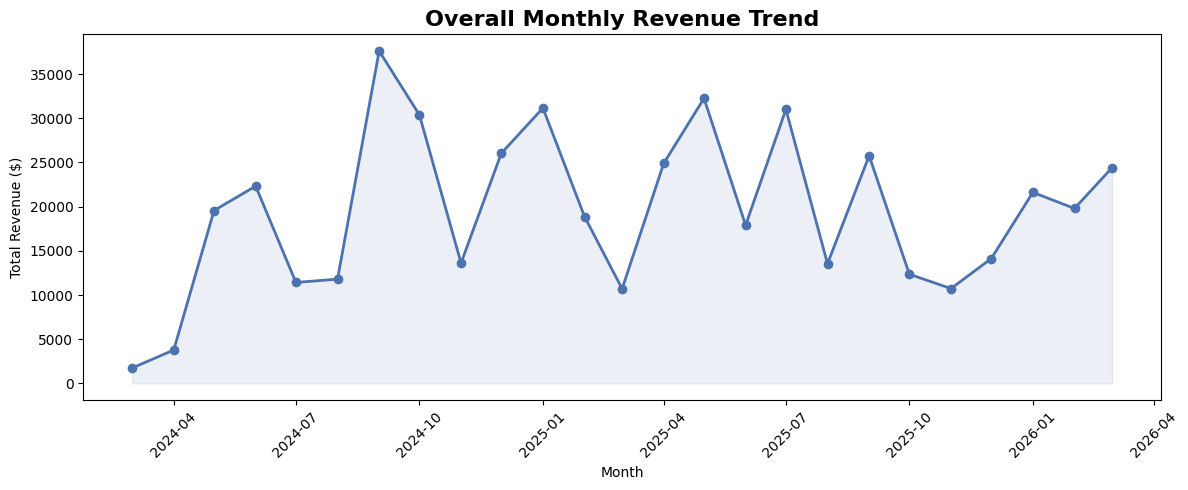

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(overall["month"], overall["revenue"], marker="o", linewidth=2, color="#4C72B0")
plt.fill_between(overall["month"], overall["revenue"], alpha=0.1, color="#4C72B0")

plt.title("Overall Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("overall_monthly_revenue.png", dpi=150)
plt.show()

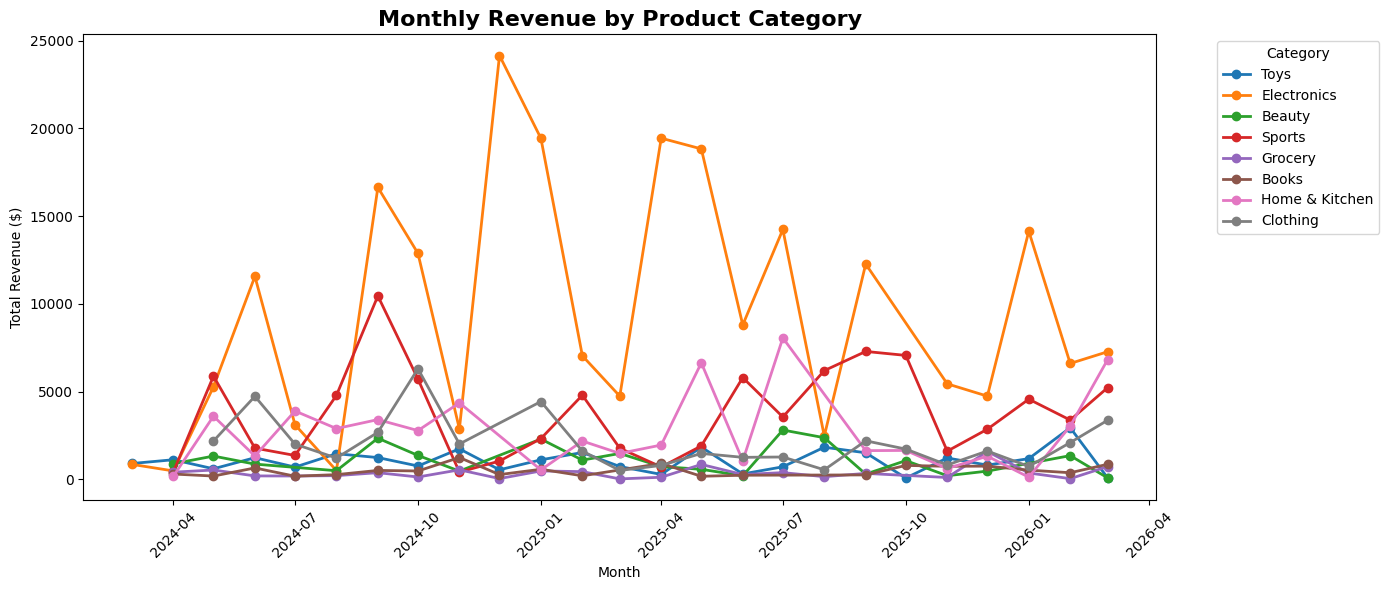

In [15]:
plt.figure(figsize=(14, 6))

for category in monthly_revenue["product_category"].unique():
    subset = monthly_revenue[monthly_revenue["product_category"] == category]
    plt.plot(subset["month"], subset["total_revenue"], marker="o", linewidth=2, label=category)

plt.title("Monthly Revenue by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("category_monthly_revenue.png", dpi=150)
plt.show()

<Axes: xlabel='product_category', ylabel='month'>

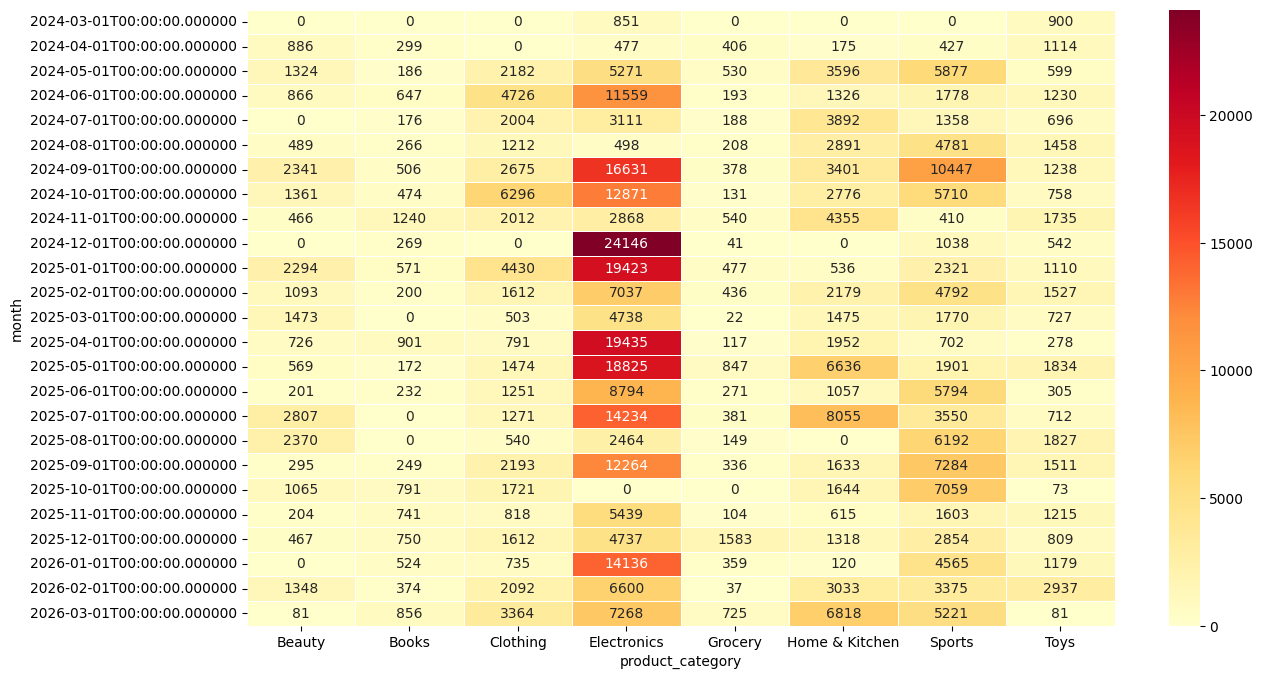

In [17]:
pivot = monthly_revenue.pivot_table(
    index="month", columns="product_category", values="total_revenue", fill_value=0
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)

